In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib

In [32]:
# Load CSV file
data = pd.read_csv("Traffic.csv")

print("Dataset Preview:")
print(data.head())

Dataset Preview:
          Time  Date Day of the week  CarCount  BikeCount  BusCount  \
0  12:00:00 AM    10         Tuesday        31          0         4   
1  12:15:00 AM    10         Tuesday        49          0         3   
2  12:30:00 AM    10         Tuesday        46          0         3   
3  12:45:00 AM    10         Tuesday        51          0         2   
4   1:00:00 AM    10         Tuesday        57          6        15   

   TruckCount  Total Traffic Situation  
0           4     39               low  
1           3     55               low  
2           6     55               low  
3           5     58               low  
4          16     94            normal  


In [33]:
print("Before Cleaning:", data.shape)

# Convert to string
data['Traffic Situation'] = data['Traffic Situation'].astype(str).str.lower()

# Replace text labels safely
data['Traffic Situation'] = data['Traffic Situation'].replace({
    'low': 0,
    'normal': 1,
    'high': 2,
    'heavy': 3
})

# Convert to numeric (handles mixed values)
data['Traffic Situation'] = pd.to_numeric(data['Traffic Situation'], errors='coerce')

# Drop missing values
data = data.dropna()

print("After Cleaning:", data.shape)

Before Cleaning: (2976, 9)
After Cleaning: (2976, 9)


C:\Users\leetika\AppData\Local\Temp\ipykernel_8352\135280243.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Traffic Situation'] = data['Traffic Situation'].replace({


In [36]:
X = data[['CarCount', 'BikeCount', 'BusCount', 'TruckCount']]
y = data['Traffic Situation']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [39]:
y_pred = model.predict(X_test) 
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)


Model Accuracy: 0.9530201342281879


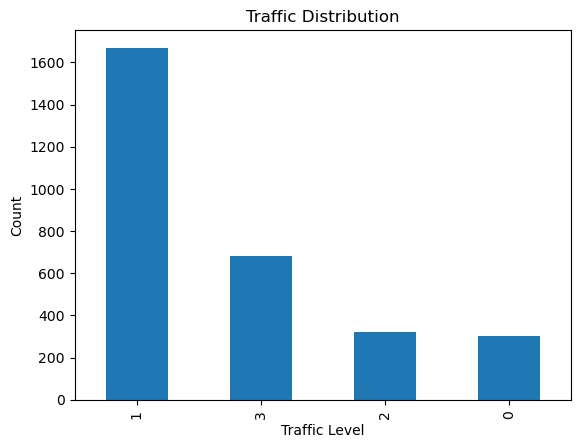

In [40]:
data['Traffic Situation'].value_counts().plot(kind='bar')
plt.title("Traffic Distribution")
plt.xlabel("Traffic Level")
plt.ylabel("Count")
plt.show()

In [41]:
joblib.dump(model, "traffic_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [42]:
sample = pd.DataFrame([[50, 20, 10, 5]],
                      columns=['CarCount', 'BikeCount', 'BusCount', 'TruckCount'])

prediction = model.predict(sample)

traffic_labels = {
    0: "Low Traffic",
    1: "Normal Traffic",
    2: "High Traffic",
    3: "Heavy Traffic"
}

print("\nPredicted Traffic Level:", traffic_labels[int(prediction[0])])


Predicted Traffic Level: Low Traffic
